In [1]:
import intake
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['UK']

In [2]:
import easygems.healpix as egh

/home/users/mmuetz/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
list(cat)

['CERES_EBAF',
 'ERA5',
 'IR_IMERG',
 'JRA3Q',
 'MERRA2',
 'casesm2_10km_nocumulus',
 'icon_d3hp003',
 'icon_d3hp003aug',
 'icon_d3hp003feb',
 'icon_ngc4008',
 'ifs_tco3999-ng5_deepoff',
 'ifs_tco3999-ng5_rcbmf',
 'ifs_tco3999-ng5_rcbmf_cf',
 'nicam_220m_test',
 'nicam_gl11',
 'scream-dkrz',
 'tracking-d3hp003',
 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_glm_n1280_CoMA9_TBv1p2',
 'um_glm_n1280_GAL9',
 'um_glm_n2560_RAL3p3']

In [6]:
ds = cat['um_glm_n1280_GAL9'](zoom=9, time='PT1H').to_dask()

/home/users/mmuetz/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [7]:
ds

<xarray.Dataset> Size: 3TB
Dimensions:  (cell: 3145728, time: 10489)
Coordinates:
  * cell     (cell) int64 25MB 0 1 2 3 4 ... 3145724 3145725 3145726 3145727
    crs      float64 8B nan
  * time     (time) datetime64[ns] 84kB 2020-01-20 ... 2021-04-01
Data variables: (12/26)
    clivi    (time, cell) float32 132GB dask.array<chunksize=(4, 262144), meta=np.ndarray>
    clt      (time, cell) float32 132GB dask.array<chunksize=(4, 262144), meta=np.ndarray>
    clwvi    (time, cell) float32 132GB dask.array<chunksize=(4, 262144), meta=np.ndarray>
    hflsd    (time, cell) float32 132GB dask.array<chunksize=(4, 262144), meta=np.ndarray>
    hfssd    (time, cell) float32 132GB dask.array<chunksize=(4, 262144), meta=np.ndarray>
    huss     (time, cell) float32 132GB dask.array<chunksize=(4, 262144), meta=np.ndarray>
    ...       ...
    tas      (time, cell) float32 132GB dask.array<chunksize=(4, 262144), meta=np.ndarray>
    ts       (time, cell) float32 132GB dask.array<chunksize=(4, 262144), meta=np.ndarray>
    uas      (time, cell) float32 132GB dask.array<chunksize=(4, 262144), meta=np.ndarray>
    vas      (time, cell) float32 132GB dask.array<chunksize=(4, 262144), meta=np.ndarray>
    orog     (cell) float64 25MB dask.array<chunksize=(98304,), meta=np.ndarray>
    sftlf    (cell) float64 25MB dask.array<chunksize=(98304,), meta=np.ndarray>
Attributes:
    Met Office DYAMOND3 simulations:  A group of experiments have been conduc...
    bounds:                           {'lower_left_lat': -90, 'lower_left_lon...
    latitiude_convention:             [-90, 90]
    longitude_convention:             [0, 360]
    regional:                         False
    simulation:                       glm.n1280_GAL9_nest

<Figure size 640x480 with 0 Axes>

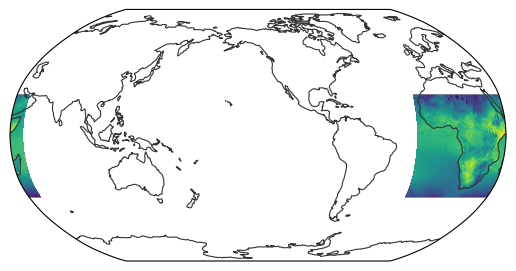

In [28]:
egh.healpix_show(ds.tas.isel(time=10))

In [ ]:
ds.isel(time=slice(None, None, 3))